## Bibliotheken importeren

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import random
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import sqlite3

## Data inlezen en kolommen selecteren

In [2]:
df = pd.read_csv("vgsales.csv", sep= ',')
print(df.head())

df = df.loc[:, ['Rank', 'Year', 'NA_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Platform', 'EU_Sales']]

# Code voor het numeriek weergeven van de echte getallen
sales_columns = ['NA_Sales', 'JP_Sales', 'EU_Sales', 'Other_Sales', 'Global_Sales']
for column in sales_columns:
    if column in df.columns: 
        df[column] = (df[column] * 1_000_000).astype(int)  

df

# DataFrame voor minder kolommen om overfitting te voorkomen
# df = df.loc[:, ['Rank', 'Year', 'NA_Sales', 'JP_Sales', 'Platform', 'EU_Sales']]
# df

# df = df.loc[:, ['Rank', 'Year', 'Platform', 'EU_Sales']]
# df

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


,Rank,Year,NA_Sales,JP_Sales,Other_Sales,Global_Sales,Platform,EU_Sales
0,1,2006.0,41490000,3770000,8460000,82740000,Wii,29020000
1,2,1985.0,29080000,6810000,770000,40240000,NES,3580000
2,3,2008.0,15850000,3790000,3310000,35820000,Wii,12880000
3,4,2009.0,15750000,3280000,2960000,33000000,Wii,11010000
4,5,1996.0,11270000,10220000,1000000,31370000,GB,8890000
...,...,...,...,...,...,...,...,...
16593,16596,2002.0,10000,0,0,10000,GBA,0
16594,16597,2003.0,10000,0,0,10000,GC,0
16595,16598,2008.0,0,0,0,10000,PS2,0
16596,16599,2010.0,0,0,0,10000,DS,10000


## Onafhankelijke niet-numerieke variabelen

## Mergen en replacen

In [3]:
dummies_dataframe = pd.get_dummies(df.loc[:, ['Platform']])

df = pd.concat([df, dummies_dataframe], axis=1)
df = df.drop(['Platform'], axis=1)
df = df.dropna(subset=['Year'])

Snijden

In [4]:
X = df.loc[df['EU_Sales'].notna(), :]
X = X.drop('EU_Sales', axis = 1)
y = df.loc[df['EU_Sales'].notna(), ['EU_Sales']]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           16327 non-null  int64  
 1   Year           16327 non-null  float64
 2   NA_Sales       16327 non-null  int64  
 3   JP_Sales       16327 non-null  int64  
 4   Other_Sales    16327 non-null  int64  
 5   Global_Sales   16327 non-null  int64  
 6   Platform_2600  16327 non-null  bool   
 7   Platform_3DO   16327 non-null  bool   
 8   Platform_3DS   16327 non-null  bool   
 9   Platform_DC    16327 non-null  bool   
 10  Platform_DS    16327 non-null  bool   
 11  Platform_GB    16327 non-null  bool   
 12  Platform_GBA   16327 non-null  bool   
 13  Platform_GC    16327 non-null  bool   
 14  Platform_GEN   16327 non-null  bool   
 15  Platform_GG    16327 non-null  bool   
 16  Platform_N64   16327 non-null  bool   
 17  Platform_NES   16327 non-null  bool   
 18  Platform_NG

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = 42
)

In [6]:
reg_model = linear_model.LinearRegression()
reg_model = LinearRegression().fit(X_train, y_train)
reg_model

LinearRegression()

In [7]:
y_pred= reg_model.predict(X_test)
y_pred

array([[ 59615.09908145],
       [ 29378.77710921],
       [160234.00207064],
       ...,
       [  -574.75918772],
       [ 18951.68617202],
       [  8729.43233614]])

In [8]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_Sales_EU'})
prediction_df

,Predicted_Sales_EU
0,59615.099081
1,29378.777109
2,160234.002071
3,600060.071154
4,-183.646188
...,...
2445,39090.790256
2446,19065.756692
2447,-574.759188
2448,18951.686172


In [9]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_Sales_EU'})
prediction_df

,Predicted_Sales_EU
0,59615.099081
1,29378.777109
2,160234.002071
3,600060.071154
4,-183.646188
...,...
2445,39090.790256
2446,19065.756692
2447,-574.759188
2448,18951.686172


In [10]:
y_test_prediction_merge = pd.concat([y_test.reset_index()['EU_Sales'], prediction_df], axis = 1)
y_test_prediction_merge.loc[y_test_prediction_merge['Predicted_Sales_EU'].notna(), :]

,EU_Sales,Predicted_Sales_EU
0,70000,59615.099081
1,30000,29378.777109
2,160000,160234.002071
3,590000,600060.071154
4,0,-183.646188
...,...,...
2445,40000,39090.790256
2446,20000,19065.756692
2447,0,-574.759188
2448,10000,18951.686172


## Uitkomst evalueren

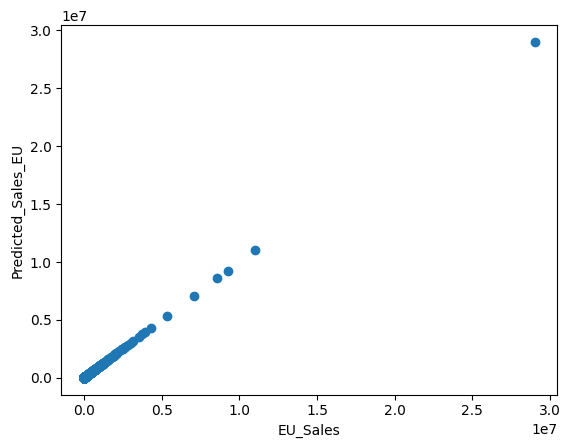

In [11]:
plt.scatter(y_test_prediction_merge['EU_Sales'], y_test_prediction_merge['Predicted_Sales_EU'])
plt.xlabel('EU_Sales')
plt.ylabel('Predicted_Sales_EU')
plt.show()

De grootte van de error verandert bij het aanpassen van de dataset. Bij het uitdrukken in miljoenen is te zien dat de error erg klein is.

De grafiek geeft nog steeds een mooie lineaire lijn

In [12]:
mean_squared_error(y_test_prediction_merge['EU_Sales'], y_test_prediction_merge['Predicted_Sales_EU'])

26750857.33989292

In [13]:
mean_absolute_error(y_test_prediction_merge['EU_Sales'], y_test_prediction_merge['Predicted_Sales_EU'])

2974.4024044501894